# 022 — Training: EfficientNet (Round 2 recipe, two-phase fine-tuning)

Trains `efficientnet_unet`/`efficientnet_unet_ft` and `efficientnet_unet_nll`/`efficientnet_unet_nll_ft` — the two architectures built on a pretrained EfficientNetB0 encoder, now under the **Round 2 recipe** (`fixing.md` §2 "Round 2 — EfficientNet, handled separately"): the custom **decoder** gets `GroupNormalization` + He init (#1/#3 — the pretrained *encoder* is left completely untouched, see `scripts.efficientnet_unet._conv_block`'s docstring), `Adam(weight_decay=...)` (#2), the unified `combined_loss` (#9, replacing `combined_loss_advanced`) for the deterministic model, and the unified `laplace_nll` loss (#10, replacing the `gaussian_nll`/`beta_nll` split) for the NLL model — the same recipe every other architecture already trains with, instead of the pre-Round-1 one this notebook used to keep.

Also implements **#6 (two-phase fine-tuning)**, previously unused: each model trains in two subprocess phases — phase 1 with the encoder frozen (`efficientnet_unet` / `efficientnet_unet_nll`), phase 2 warm-started from phase 1's weights with the encoder unfrozen (`efficientnet_unet_ft` / `efficientnet_unet_nll_ft`, `--init-from`), saved as **separate checkpoints** so the frozen-encoder baseline is never overwritten — `052_model_comparison.ipynb` can then compare both directly. Each phase runs in its own **subprocess** via `scripts/train_single.py` (`fixing.md` §7.1), closing the last architecture family that still trained in an in-process loop (previously the source of the GPU-state-accumulation `NaN` pattern `020_training.ipynb` hit before that fix). See `020_training.ipynb`'s title cell for the full table of companion notebooks.

Only the **artwork-and-mockups** split is used (see §1).

Make the project root importable so `scripts.*` resolves regardless of
the notebook's working directory.

In [1]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

Imports, a fixed global seed, and a GPU sanity check. `json`/`subprocess`
are needed here (unlike `020`/`021`) because this notebook launches two
subprocess phases per model rather than one.

In [2]:
import json
import subprocess

import matplotlib.pyplot as plt
import tensorflow as tf

from scripts.config import settings
from scripts.dataset import (
    build_dataset,
    load_image_pairs,
    mockup_aware_train_val_test_split,
)
from scripts.reproducibility import set_global_seed
from scripts.visualization import plot_training_curves

set_global_seed()

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")
print(f"TensorFlow version: {tf.__version__}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version: 2.16.2


## 1. Dataset — artwork-and-mockups split

Same split as `020`/`021`/`023` §1 — required so these checkpoints are
trained and evaluated under the same conditions as the rest of the
project.

In [3]:
pairs = load_image_pairs(settings.IR_DIR, settings.RGB_DIR)
train_pairs, val_pairs, _ = mockup_aware_train_val_test_split(
    pairs,
    train_ratio=settings.TRAIN_RATIO,
    val_ratio=settings.VAL_RATIO,
    mockup_ids=settings.MOCKUP_ARTWORK_IDS,
    mockup_test_ratio=settings.MOCKUP_TEST_RATIO,
    seed=settings.SEED,
)

train_ds = build_dataset(
    train_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=True,
    shuffle=True,
    seed=settings.SEED,
    crop_size=settings.CROP_SIZE,
)
val_ds = build_dataset(
    val_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=False,
    shuffle=False,
)

print(f"Train: {len(train_pairs)} patches ({len(train_ds)} batches)")
print(f"Val:   {len(val_pairs)} patches ({len(val_ds)} batches)")

Train: 863 patches (108 batches)
Val:   166 patches (21 batches)


2026-08-26 09:52:51.924899: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-26 09:52:51.924921: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-26 09:52:51.924926: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-26 09:52:51.924939: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-26 09:52:51.924948: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## 2. Loss functions

| Model | Loss |
|---|---|
| `efficientnet_unet` / `efficientnet_unet_ft` | `combined_loss` — `0.16 · Charbonnier + 0.84 · (1 − MS-SSIM)`, same as every other deterministic architecture (`fixing.md` #9) |
| `efficientnet_unet_nll` / `efficientnet_unet_nll_ft` | `laplace_nll_loss`, β=0.5 — same as `unet_nll`/`resunet_nll`/`attention_unet_nll` (`fixing.md` #10) |

Both models previously trained with EfficientNet-specific losses: `combined_loss_advanced` (MAE + Laplacian pyramid + FFT, no perceptual term) for the deterministic model, and both Gaussian NLL variants for the heteroscedastic one. Round 2 unifies them onto the same losses the rest of the project uses: `combined_loss` gives `efficientnet_unet` a perceptual (MS-SSIM) term for the first time, at the deliberate cost of dropping the Laplacian-pyramid/FFT terms (a real trade-off worth confirming empirically, not assumed as a pure improvement — see `fixing.md` §4); `laplace_nll_loss` collapses the `gaussian_nll`/`beta_nll` checkpoint split into one, closing the same comparison axis `fixing.md` #10 already closed for the other three NLL architectures. `combined_loss_advanced` itself is unchanged and still unit-tested in `scripts/losses.py` — just no longer selected by any architecture's default training path (`scripts.trainer.compile_model`).

## 3. Train the deterministic model — two-phase fine-tuning

Phase 1 trains `efficientnet_unet` with the encoder frozen (`freeze_encoder=True`, the default) — the decoder learns against fixed pretrained features. Phase 2 unfreezes the encoder (`--kwargs '{"freeze_encoder": false}'`) and continues training end-to-end, **warm-started from phase 1's weights** via `--init-from` (`scripts/train_single.py`, `fixing.md` #6) — a plain `model.load_weights(...)` load is sufficient since the architecture is identical between phases and only `trainable` differs. Phase 2 uses a much lower learning rate (`settings.FINETUNE_LEARNING_RATE`, 10x below `settings.LEARNING_RATE`) and a shorter epoch budget (`settings.FINETUNE_EPOCHS`) — large steps this late risk destroying the pretrained ImageNet features rather than refining them. Phase 2's result is saved as a **separate** checkpoint, `efficientnet_unet_ft`, so the frozen-encoder baseline from phase 1 is preserved instead of overwritten (`fixing.md` §2's resolution to the "save fine-tuning separately?" question). Each phase runs in its own subprocess, same reasoning as `020_training.ipynb` §3 (`fixing.md` §7.1: sequential `model.fit()` calls in one process leak GPU state on this hardware). Set `EPOCHS = 2` for a quick smoke test before committing to a full run.

> **Note:** downloads EfficientNetB0 ImageNet weights on first use.
> Subsequent runs use the local Keras cache.

In [4]:
EPOCHS = settings.EPOCHS  # -- lower for a quick smoke test
DET_MODEL_DIR = settings.MODELS_DIR / "deterministic"
DET_LOG_DIR = settings.LOGS_DIR / "deterministic"

det_histories: dict = {}

# Phase 1 (frozen encoder) -> "efficientnet_unet"; phase 2 (unfrozen,
# warm-started from phase 1) -> the separate "efficientnet_unet_ft"
# checkpoint (fixing.md #6).
DET_PHASES = [
    {
        "arch": "efficientnet_unet",
        "epochs": EPOCHS,
        "lr": settings.LEARNING_RATE,
        "kwargs": {},
        "init_from": None,
    },
    {
        "arch": "efficientnet_unet_ft",
        "epochs": settings.FINETUNE_EPOCHS,
        "lr": settings.FINETUNE_LEARNING_RATE,
        "kwargs": {"freeze_encoder": False},
        "init_from": DET_MODEL_DIR / "efficientnet_unet" / "best_model.keras",
    },
]

for phase in DET_PHASES:
    print(f"\n{'=' * 60}")
    print(f"  Architecture: {phase['arch']}")
    print(f"{'=' * 60}")

    cmd = [
        sys.executable,
        "-m",
        "scripts.train_single",
        "--arch",
        phase["arch"],
        "--epochs",
        str(phase["epochs"]),
        "--model-dir",
        str(DET_MODEL_DIR),
        "--log-dir",
        str(DET_LOG_DIR),
        "--kwargs",
        json.dumps(phase["kwargs"]),
        "--lr",
        str(phase["lr"]),
    ]
    if phase["init_from"] is not None:
        cmd += ["--init-from", str(phase["init_from"])]

    subprocess.run(cmd, cwd=project_root, check=True)

    history_path = DET_MODEL_DIR / phase["arch"] / "history.json"
    det_histories[phase["arch"]] = json.loads(history_path.read_text())

    best_val_loss = min(det_histories[phase["arch"]]["val_loss"])
    print(f"\nBest val_loss ({phase['arch']}): {best_val_loss:.4f}")


  Architecture: efficientnet_unet


2026-08-26 09:52:54.288229: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-26 09:52:54.288247: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-26 09:52:54.288252: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-26 09:52:54.288264: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-26 09:52:54.288272: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



  Architecture: efficientnet_unet
Model: "efficientnet_unet"
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1         │ (None, None,      │           0 │ -                  │
│ (InputLayer)          │ None, 3)          │             │                    │
├───────────────────────┼──────��────────────┼─────────────┼────────────────────┤
│ multiply (Multiply)   │ (None, None,      │           0 │ input_layer_1[0][… │
│                       │ None, 3)          │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ efficientnet_b0_enco… │ [(None, None,     │   4,049,571 │ multiply[0][0]     │
│ (Functional)          │ None, 16), (None, │             │                    │
│                       │ None, None, 24),  │ 

/opt/miniconda3/envs/deep-layers/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-08-26 09:52:57.893105: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - loss: 0.5312 - mae: 0.2392 - psnr: 11.4339 - ssim: 0.0407
Epoch 1: val_loss improved from None to 0.43900, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic/efficientnet_unet/best_model.keras

Epoch 1: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic/efficientnet_unet/best_model.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 43s 306ms/step - loss: 0.5312 - mae: 0.2392 - psnr: 11.4339 - ssim: 0.0407 - val_loss: 0.4390 - val_mae: 0.2453 - val_psnr: 11.5840 - val_ssim: 0.0726 - learning_rate: 1.0000e-04
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - loss: 0.3964 - mae: 0.2125 - psnr: 13.1717 - ssim: 0.1494
Epoch 2: val_loss improved from 0.43900 to 0.33419, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic/efficientnet_unet/best_model.keras

Epoch 2: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/

2026-08-26 10:18:34.249115: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-26 10:18:34.249134: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-26 10:18:34.249139: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-26 10:18:34.249150: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-26 10:18:34.249159: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



  Architecture: efficientnet_unet_ft
Initializing weights from /Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic/efficientnet_unet/best_model.keras
Model: "efficientnet_unet"
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1         │ (None, None,      │           0 │ -                  │
│ (InputLayer)          │ None, 3)          │             │                    │
├───────────────────────┼──────��────────────┼─────────────┼────────────────────┤
│ multiply (Multiply)   │ (None, None,      │           0 │ input_layer_1[0][… │
│                       │ None, 3)          │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ efficientnet_b0_enco… │ [(None, None,     │   4,049,571 │ multiply[0][0]

/opt/miniconda3/envs/deep-layers/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-08-26 10:18:41.945495: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 830ms/step - loss: 0.2995 - mae: 0.1845 - psnr: 15.4862 - ssim: 0.5806
Epoch 1: val_loss improved from None to 0.25937, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic/efficientnet_unet_ft/best_model.keras

Epoch 1: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic/efficientnet_unet_ft/best_model.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 128s 903ms/step - loss: 0.2995 - mae: 0.1845 - psnr: 15.4862 - ssim: 0.5806 - val_loss: 0.2594 - val_mae: 0.2019 - val_psnr: 14.5722 - val_ssim: 0.6591 - learning_rate: 1.0000e-05
Epoch 2/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 772ms/step - loss: 0.2893 - mae: 0.1841 - psnr: 15.5423 - ssim: 0.5904
Epoch 2: val_loss did not improve from 0.25937
108/108 ━━━━━━━━━━━━━━━━━━━━ 85s 785ms/step - loss: 0.2893 - mae: 0.1841 - psnr: 15.5423 - ssim: 0.5904 - val_loss: 0.2721 - val_mae: 0.2027 - val_psnr: 14.5243 - val_ssim: 0.6495 - learning_rate: 1.0000e-05
Epo

## 4. Train the NLL model — two-phase fine-tuning

Same two-phase structure as §3, for the heteroscedastic `(mu, log_b)` counterpart: phase 1 trains `efficientnet_unet_nll` with the encoder frozen; phase 2 (`efficientnet_unet_nll_ft`) unfreezes it, warm-started from phase 1's weights, at `settings.FINETUNE_LEARNING_RATE` for up to `settings.FINETUNE_EPOCHS`. Both phases train with the unified `laplace_nll` loss (`fixing.md` #10). Implementing an NLL `_ft` variant symmetrically with the deterministic one above was a small marginal addition once `--init-from`/the `_BUILDERS_NLL` entry existed for it — `fixing.md` §0 records this as the resolution to the one point the plan left ambiguous (only the deterministic checkpoint-naming question was spelled out explicitly).

In [5]:
NLL_MODEL_DIR = settings.MODELS_DIR / "nll"
NLL_LOG_DIR = settings.LOGS_DIR / "nll"

nll_histories: dict = {}

NLL_PHASES = [
    {
        "arch": "efficientnet_unet_nll",
        "epochs": EPOCHS,
        "lr": settings.LEARNING_RATE,
        "kwargs": {},
        "init_from": None,
    },
    {
        "arch": "efficientnet_unet_nll_ft",
        "epochs": settings.FINETUNE_EPOCHS,
        "lr": settings.FINETUNE_LEARNING_RATE,
        "kwargs": {"freeze_encoder": False},
        "init_from": NLL_MODEL_DIR / "efficientnet_unet_nll" / "best_model.keras",
    },
]

for phase in NLL_PHASES:
    print(f"\n{'=' * 60}")
    print(f"  Architecture: {phase['arch']}")
    print(f"{'=' * 60}")

    cmd = [
        sys.executable,
        "-m",
        "scripts.train_single",
        "--arch",
        phase["arch"],
        "--epochs",
        str(phase["epochs"]),
        "--model-dir",
        str(NLL_MODEL_DIR),
        "--log-dir",
        str(NLL_LOG_DIR),
        "--kwargs",
        json.dumps(phase["kwargs"]),
        "--lr",
        str(phase["lr"]),
        "--nll",
        "--loss-name",
        "laplace_nll",
    ]
    if phase["init_from"] is not None:
        cmd += ["--init-from", str(phase["init_from"])]

    subprocess.run(cmd, cwd=project_root, check=True)

    history_path = NLL_MODEL_DIR / phase["arch"] / "history.json"
    nll_histories[phase["arch"]] = json.loads(history_path.read_text())

    best_val_loss = min(nll_histories[phase["arch"]]["val_loss"])
    print(f"\nBest val_loss ({phase['arch']}): {best_val_loss:.4f}")


  Architecture: efficientnet_unet_nll


2026-08-26 10:48:00.024556: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-26 10:48:00.024575: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-26 10:48:00.024579: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-26 10:48:00.024592: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-26 10:48:00.024601: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



  Architecture: efficientnet_unet_nll
Model: "efficientnet_unet_nll"
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1         │ (None, None,      │           0 │ -                  │
│ (InputLayer)          │ None, 3)          │             │                    │
├───────────────────────┼──────��────────────┼─────────────┼────────────────────┤
│ multiply (Multiply)   │ (None, None,      │           0 │ input_layer_1[0][… │
│                       │ None, 3)          │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ efficientnet_b0_enco… │ [(None, None,     │   4,049,571 │ multiply[0][0]     │
│ (Functional)          │ None, 16), (None, │             │                    │
│                       │ None, None, 

/opt/miniconda3/envs/deep-layers/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-08-26 10:48:03.343801: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - loss: 0.2665 - mae: 0.2357 - psnr: 11.6385 - ssim: 0.0441
Epoch 1: val_loss improved from None to 0.06550, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/nll/efficientnet_unet_nll/best_model.keras

Epoch 1: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/nll/efficientnet_unet_nll/best_model.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 42s 315ms/step - loss: 0.2665 - mae: 0.2357 - psnr: 11.6385 - ssim: 0.0441 - val_loss: 0.0655 - val_mae: 0.2429 - val_psnr: 11.7544 - val_ssim: 0.0768 - learning_rate: 1.0000e-04
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - loss: -0.1219 - mae: 0.2101 - psnr: 13.2065 - ssim: 0.1100
Epoch 2: val_loss improved from 0.06550 to -0.18942, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/nll/efficientnet_unet_nll/best_model.keras

Epoch 2: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/nll/efficientnet

2026-08-26 11:07:15.948657: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-26 11:07:15.948678: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-26 11:07:15.948683: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-26 11:07:15.948694: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-26 11:07:15.948702: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



  Architecture: efficientnet_unet_nll_ft
Initializing weights from /Users/simonecaglio/Documents/GitHub/deep_layers/models/nll/efficientnet_unet_nll/best_model.keras
Model: "efficientnet_unet_nll"
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1         │ (None, None,      │           0 │ -                  │
│ (InputLayer)          │ None, 3)          │             │                    │
├───────────────────────┼──────��────────────┼─────────────┼────────────────────┤
│ multiply (Multiply)   │ (None, None,      │           0 │ input_layer_1[0][… │
│                       │ None, 3)          │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ efficientnet_b0_enco… │ [(None, None,     │   4,049,571 │ multiply[0][

/opt/miniconda3/envs/deep-layers/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-08-26 11:07:23.377895: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 859ms/step - loss: -0.3356 - mae: 0.1502 - psnr: 16.3023 - ssim: 0.3635
Epoch 1: val_loss improved from None to -0.30293, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/nll/efficientnet_unet_nll_ft/best_model.keras

Epoch 1: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/nll/efficientnet_unet_nll_ft/best_model.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 130s 920ms/step - loss: -0.3356 - mae: 0.1502 - psnr: 16.3023 - ssim: 0.3635 - val_loss: -0.3029 - val_mae: 0.1653 - val_psnr: 15.7228 - val_ssim: 0.4780 - learning_rate: 1.0000e-05
Epoch 2/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 804ms/step - loss: -0.3565 - mae: 0.1445 - psnr: 16.5515 - ssim: 0.3712
Epoch 2: val_loss did not improve from -0.30293
108/108 ━━━━━━━━━━━━━━━━━━━━ 88s 815ms/step - loss: -0.3565 - mae: 0.1445 - psnr: 16.5515 - ssim: 0.3712 - val_loss: -0.2631 - val_mae: 0.1828 - val_psnr: 15.0856 - val_ssim: 0.4266 - learning_rate: 1.0000e-05
Epoch 3

## 5. Training curves

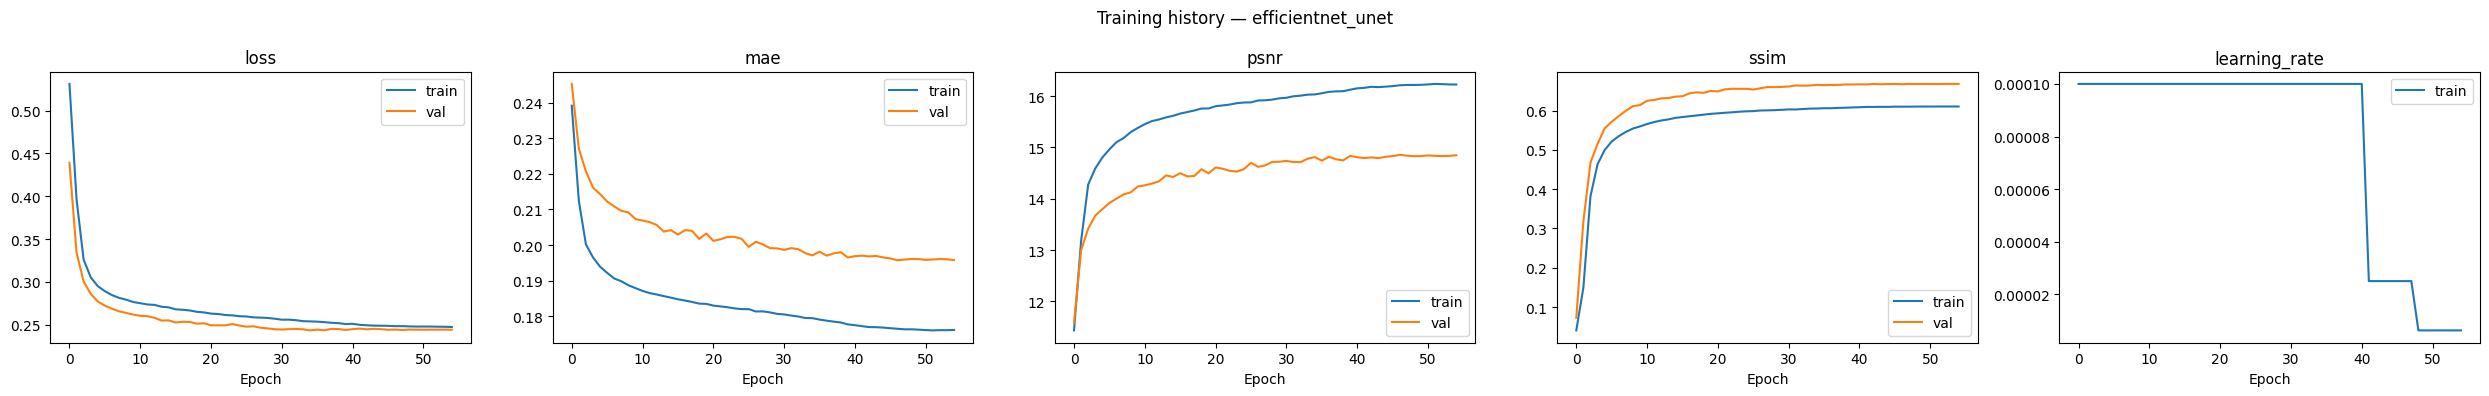

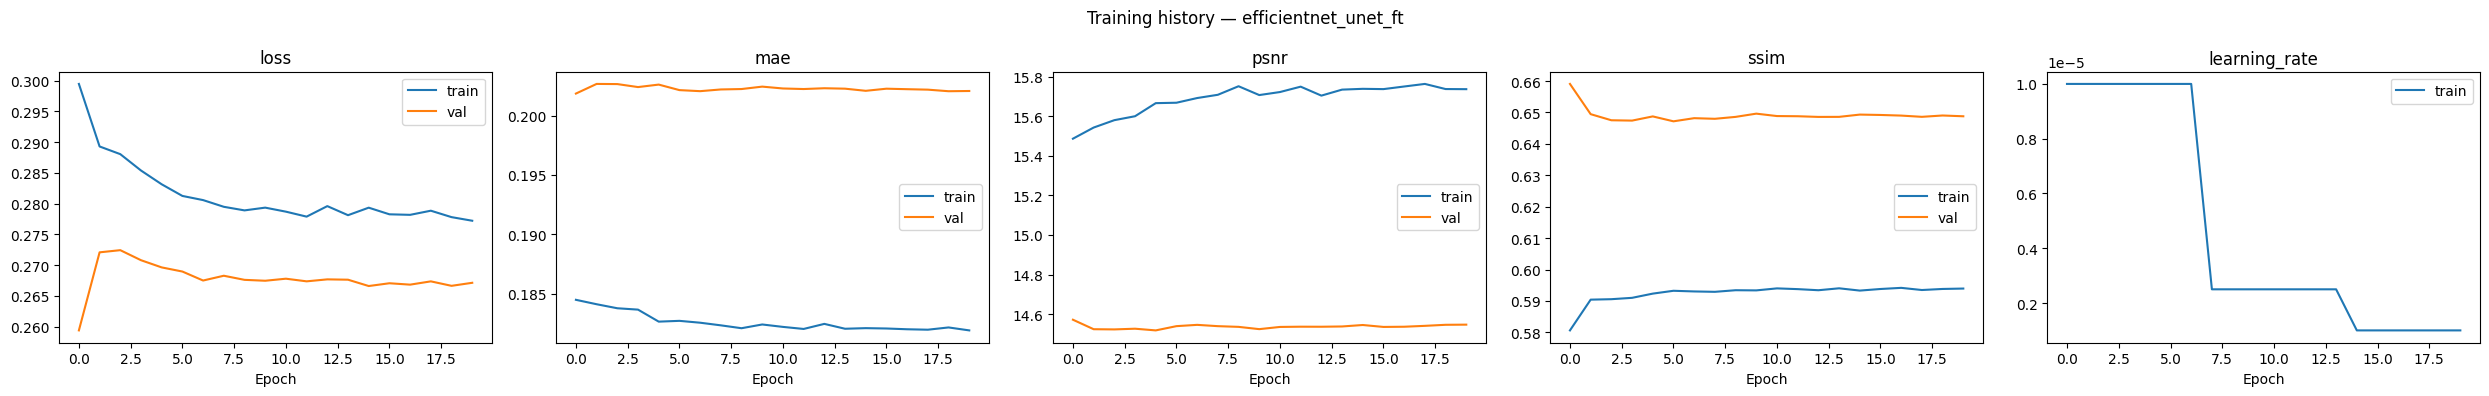

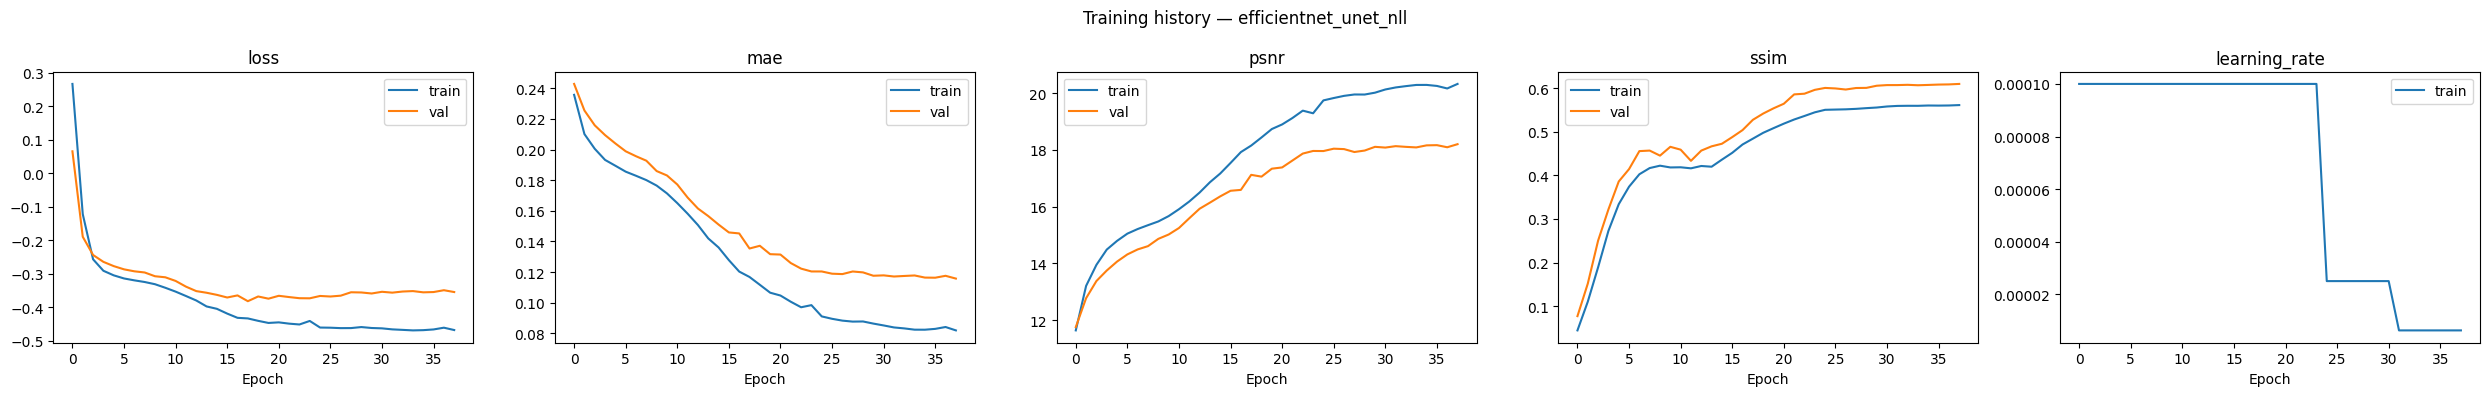

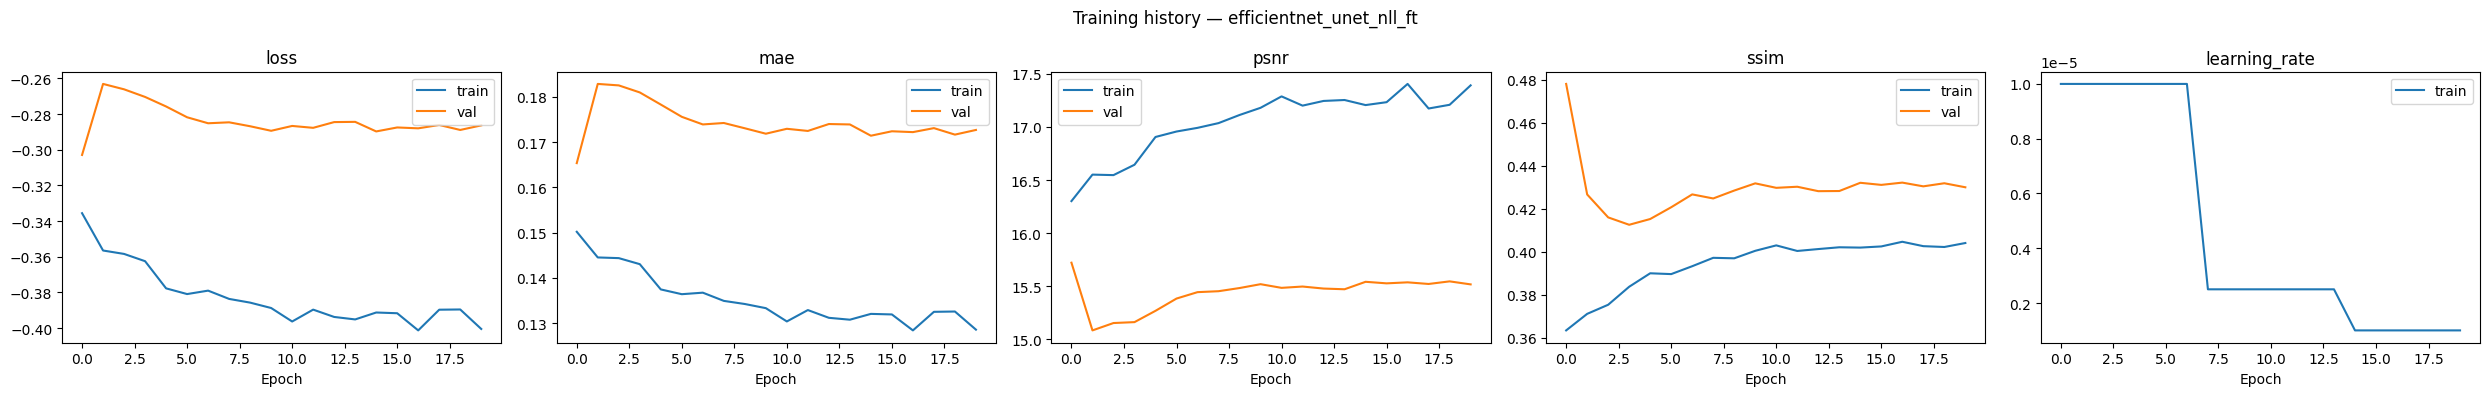

In [6]:
for arch, history in det_histories.items():
    plot_training_curves(history, title=f"Training history — {arch}")
    plt.show()

for arch, history in nll_histories.items():
    plot_training_curves(history, title=f"Training history — {arch}")
    plt.show()

## 6. Summary

Checkpoints saved to `models/deterministic/efficientnet_unet/best_model.keras`,
`models/deterministic/efficientnet_unet_ft/best_model.keras`,
`models/nll/efficientnet_unet_nll/best_model.keras`, and
`models/nll/efficientnet_unet_nll_ft/best_model.keras`. Logs under the
matching `logs/` subtrees.

In [7]:
checks = [
    ("efficientnet_unet", DET_MODEL_DIR),
    ("efficientnet_unet_ft", DET_MODEL_DIR),
    ("efficientnet_unet_nll", NLL_MODEL_DIR),
    ("efficientnet_unet_nll_ft", NLL_MODEL_DIR),
]
for arch, model_dir in checks:
    ckpt = model_dir / arch / "best_model.keras"
    status = "found" if ckpt.exists() else "MISSING"
    print(f"{arch:<25} ({model_dir.name:<12}): {status}  ({ckpt})")

efficientnet_unet         (deterministic): found  (/Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic/efficientnet_unet/best_model.keras)
efficientnet_unet_ft      (deterministic): found  (/Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic/efficientnet_unet_ft/best_model.keras)
efficientnet_unet_nll     (nll         ): found  (/Users/simonecaglio/Documents/GitHub/deep_layers/models/nll/efficientnet_unet_nll/best_model.keras)
efficientnet_unet_nll_ft  (nll         ): found  (/Users/simonecaglio/Documents/GitHub/deep_layers/models/nll/efficientnet_unet_nll_ft/best_model.keras)
